In [1]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Rajput@1412',
    database='walmart'
)

cur=db.cursor()


**QUESTION:1** How many unique product lines does the data have?

In [5]:
query="""SELECT  COUNT(DISTINCT product_line) AS total FROM sales
UNION ALL
SELECT product_line from (SELECT DISTINCT product_line FROM sales) AS distinct_products;
"""
cur.execute(query)
data=cur.fetchall()
data
df=pd.DataFrame(data)
df.columns=['product_line']
df

,product_line
0,6
1,Food and beverages
2,Health and beauty
3,Sports and travel
4,Fashion accessories
5,Home and lifestyle
6,Electronic accessories


**QUESTION:2**  What is the most common payment method?


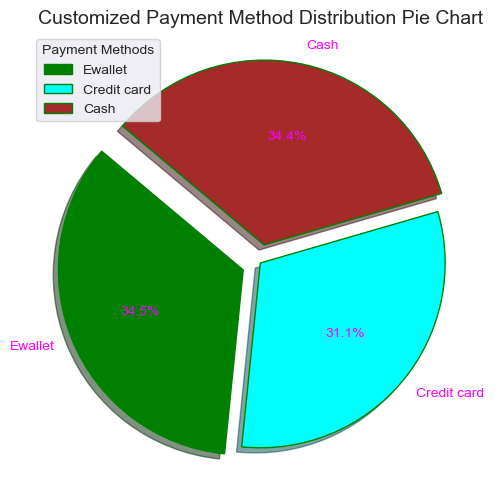

In [31]:
query="""select payment,count(payment) from sales group by payment order by payment desc
"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['payment','count']
colors = ['green', 'cyan', 'brown']
explode = (0.1, 0, 0.1)  # Exploding specific slices

# Create Pie Chart
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    df['count'],
    labels=df['payment'],
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    colors=colors,
    shadow=True,
    wedgeprops={'edgecolor': 'green'}
)

# Customize text colors
for text in texts:
    text.set_color('magenta')  # Label color
for autotext in autotexts:
    autotext.set_color('magenta')  # Percentage color

# Add Title
plt.title("Customized Payment Method Distribution Pie Chart", fontsize=14)

# Add Legend
plt.legend(df['payment'], title="Payment Methods", loc="best")

# Show Chart
plt.show()

**QUESTION:3** What is the most selling product line?

In [32]:
query="""select product_line, sum(quantity) as total  from sales group by product_line order by total desc"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['product_line','total']
df


,product_line,total
0,Electronic accessories,971
1,Food and beverages,952
2,Sports and travel,920
3,Home and lifestyle,911
4,Fashion accessories,902
5,Health and beauty,854


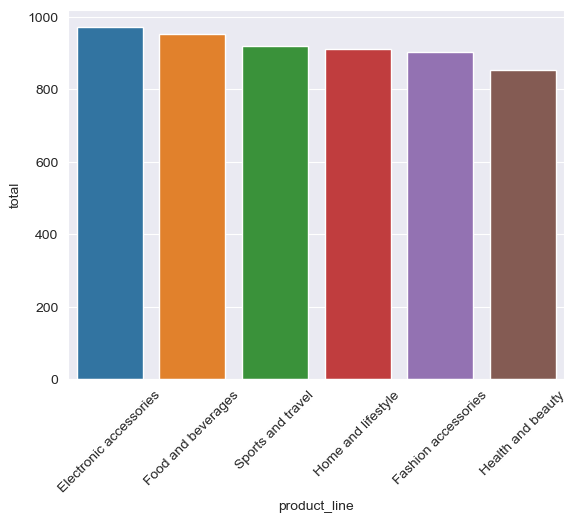

In [33]:
sns.barplot(x='product_line',y='total',data=df,)
plt.xticks(rotation=45)
plt.show()

**QUESTION:4** What is the total revenue by month?

In [34]:
 query="""select sum(total),monthname(date),month(date) from sales group by monthname(date),month(date) order by month(date)"""

 cur.execute(query)
 data=cur.fetchall()
 df=pd.DataFrame(data)
df

,0,1,2
0,116291.8680,January,1
1,97219.3740,February,2
2,109455.5070,March,3


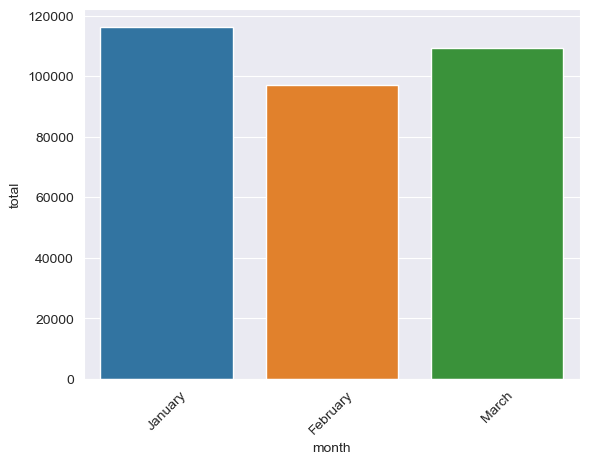

In [35]:
 df.columns=['total','month','month_num']
 sns.barplot(x='month',y='total',data=df)
 plt.xticks(rotation=45)
 plt.show()

**QUESTION :5** What month had the largest COGS?


In [36]:
query="""select monthname(date),month(date),
sum(unit_price*quantity) from sales group by month(date),monthname(date) order by month(date)"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['month','month_no','cogs']
df



,month,month_no,cogs
0,January,1,110812
1,February,2,92595
2,March,3,104234


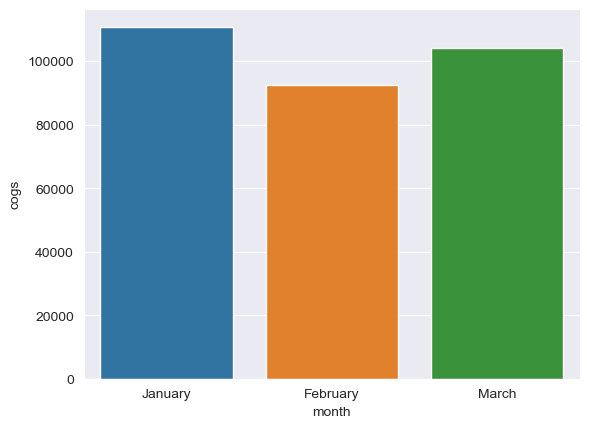

In [37]:
sns.barplot(x='month',y='cogs',data=df)
df['cogs'] = df['cogs'].astype(float)

**QUESTION:6** What product line had the largest revenue?

In [38]:
query="""select product_line,sum(total) as Revenue from sales group by product_line order by Revenue desc"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['product_line','Revenue']
df


,product_line,Revenue
0,Food and beverages,56144.8440
1,Sports and travel,55122.8265
2,Electronic accessories,54337.5315
3,Fashion accessories,54305.8950
4,Home and lifestyle,53861.9130
5,Health and beauty,49193.7390


**QUESTION :7:** What is the city with the largest revenue?

In [39]:
query="""SELECT city, ROUND(SUM(total), 2) as total_by_city
FROM sales
GROUP BY city
order by total_by_city desc"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['city','total_by_city']
df

,city,total_by_city
0,Naypyitaw,110568.71
1,Yangon,106200.37
2,Mandalay,106197.67


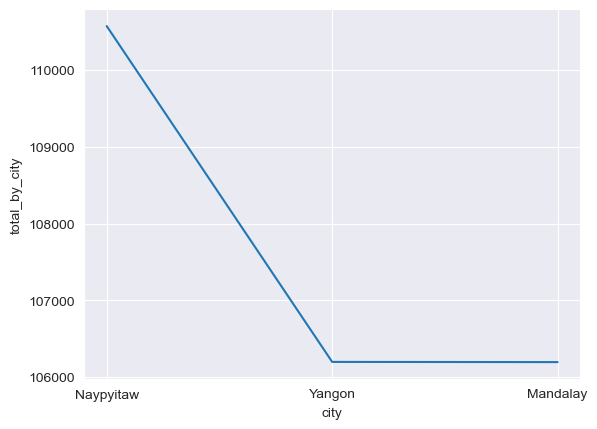

In [40]:
sns.lineplot(data=df,x='city',y='total_by_city')
plt.show()

**QUESTION:8** What product line had the largest VAT?


In [41]:
query=""" with cogs as (select year(date) as years,sum(unit_price*quantity) as total from sales group by year(date))
select years,round((total*5)/100,2) as vat_tax from cogs"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['vat_tax','year']
df

,vat_tax,year
0,2019,15382.05


**QUESTION** 9 Fetch each product line and add a column to those product line showing "Good", "Bad". Good if its greater than average sales

In [3]:
query="""select product_line,case when sum(total) > avg(total) then 'good' else 'bad'
    END AS rating from sales group by product_line"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['product_line','rating']
df

,product_line,rating
0,Food and beverages,good
1,Health and beauty,good
2,Sports and travel,good
3,Fashion accessories,good
4,Home and lifestyle,good
5,Electronic accessories,good


**QUESTION: 10** Which branch sold more products than average product sold?

In [4]:
query="""select branch, round(sum(total),2) as br_total from sales group by branch order by br_total desc"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['branch','total']
df


,branch,total
0,C,110568.71
1,A,106200.37
2,B,106197.67


**QUESTION:11**  What is the most common product line by gender?

In [5]:
query="""select count(product_line) counts , gender,product_line from sales group by gender,product_line , product_line order by counts desc"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['counts','gender','product_line']
df

,counts,gender,product_line
0,96,Female,Fashion accessories
1,90,Female,Food and beverages
2,88,Male,Health and beauty
3,88,Female,Sports and travel
4,86,Male,Electronic accessories
5,84,Male,Food and beverages
6,84,Female,Electronic accessories
7,82,Male,Fashion accessories
8,81,Male,Home and lifestyle
9,79,Female,Home and lifestyle


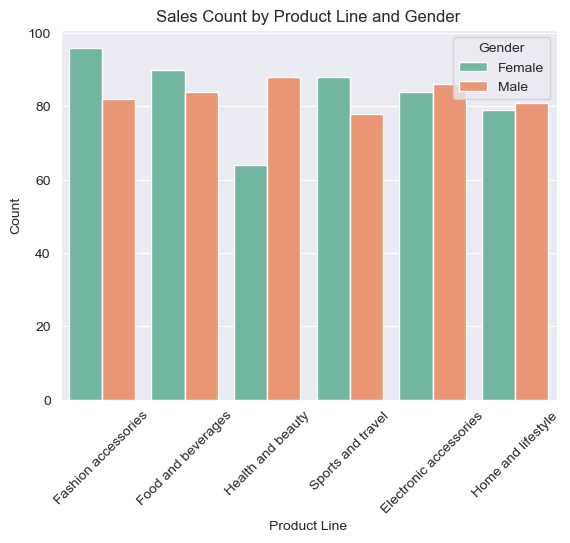

In [9]:
sns.barplot(x='product_line', y='counts', hue='gender', data=df, palette='Set2')

# Labels and Title
plt.xlabel('Product Line')
plt.ylabel('Count')
plt.title('Sales Count by Product Line and Gender')
plt.xticks(rotation=45)
plt.legend(title='Gender')

# Show Plot
plt.show()

**QUESTION :12** What is the average rating of each product line?


In [12]:
query="""select round(avg(rating),2),product_line from sales group by product_line"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['avg_rating','product_line']
df

,avg_rating,product_line
0,7.11,Food and beverages
1,7.00,Health and beauty
2,6.92,Sports and travel
3,7.03,Fashion accessories
4,6.84,Home and lifestyle
5,6.92,Electronic accessories


**CUSTOMER RELATED QUESTION **

**===================================================================================================**

*QUESTION:1**  How many unique customer types does the data have?


In [3]:
query="""select distinct(customer_type) from sales"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.columns=['customer_type']
df

,customer_type
0,Normal
1,Member
